# Tutorials for nonlinear theoretical predictions for the spectroscopic observables
## Galaxy power spectrum multipoles from comet

__Warning__: to run this part of the notebook it is necessary to first install the comet package. To do so, just get the last version (2.0.5) of the code from PyPI with `pip install comet-emu`

__Please note__: in case you already have a previous installation of comet (1.x) in your system (or environment), the installation of this specific version could create some incompatibility issues. Therefore, we recommend to create a fresh new environment and installing this version from scratch. Alternatively, you can uninstall your current version of comet with `pip uninstall comet-emu`, explicitly removing the comet folder from your installation path, and finally installing the new PyPI version.

The first section generates predictions for the EFT model, with examples on impact of Alcock-Paczinsky distortions and changes in the nuisance parameters and cosmological parameters. The final part of this block shows how to get predictions from the VDG model

In [1]:
# General imports
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy import integrate
from copy import deepcopy
from astropy.io import fits
import time

# Euclid imports
from cloelib.cosmology.camb_cosmology import CAMBBackground, CAMBLinearPerturbations, CAMBNonLinearPerturbations
from cloelib.observables.CometEFT_spectro import CometEFT_SpectroPower
from cloelib.observables.CometVDG_spectro import CometVDG_SpectroPower

from cloelib.summary_statistics.legendre_multipoles import LegendreMultipoles

# Plot style
import seaborn as sns
sns.set_theme(style="ticks")
sns.set_palette(sns.color_palette("Paired"))

plt.rc('xtick',labelsize=20)
plt.rc('ytick',labelsize=20)
plt.rc('font',size=20)
plt.rc('axes', titlesize=25)
plt.rc('axes', labelsize=20)
plt.rc('lines', linewidth=3)
plt.rc('lines', markersize=6)
plt.rc('legend', fontsize=14)

Warning! "libgrid.so" not found, bispectrum binning options will not be available.


### Define background cosmology and fiducial background and create instances of CAMBBackground for both

In [2]:
H0_fid = 67.7
Omega_cdm0_fid = 0.27
Omega_b0 = 0.049
Omega_k0 = 0.0
w0 = -1.0
wa = 0.0
ns = 0.96
As = 2.1e-9
gamma_MG = 0.545
mnu = 0.0
N_mnu = 0

background_fiducial = CAMBBackground(
    H0=H0_fid, Omega_cdm0=Omega_cdm0_fid, Omega_b0=Omega_b0, Omega_k0=Omega_k0,
    w0=w0, wa=wa, ns=ns, As=As, gamma_MG=gamma_MG, mnu=mnu, N_mnu=N_mnu
)

Omega_cdm0 = 0.28
H0 = 70.0

background = CAMBBackground(
    H0=H0, Omega_cdm0=Omega_cdm0, Omega_b0=Omega_b0, Omega_k0=Omega_k0,
    w0=w0, wa=wa, ns=ns, As=As, gamma_MG=gamma_MG, mnu=mnu, N_mnu=N_mnu
)

Then we pick a redshift, create a dictionary with nuisance (bias and counterterm) parameters for comet and create an instance of `CometEFT_SpectroPower`, which contains $P(k,\mu)$. This is based on the previously defined instance of `CAMBBackground` and the nuisance parameter dictionary

In [3]:
# Choose redshift
zs = [1.]

RSD_parameters = {
 'b1': 1.412, 'b2': 0.695, 'bG2': -0.156, 'bGam3': 0.323,
 'c0': 30.948, 'c2': 46.233, 'c4': 10.057, 'cnlo': 0.0
}
pkmu_comet = CometEFT_SpectroPower(background, RSD_parameters, redshift=zs[0])                            

We create a dictionary with noise and systematic parameters, and create an instance of `LegendreMultipoles` based on `pkmu_comet`, the noise and systematics parameters. We also need to specify a value for the number density  $\bar{n}$ and a fiducial background cosmology (used to apply Alcock-Paczinsky distortions)

In [4]:
noise_syst_parameters = {
 'NP0': 1.056, 'NP20': 0.0, 'NP22': 0.0,
 'fout': 0.0, 'sigmaz': 0.0
}
mps_comet = LegendreMultipoles(pkmu_comet, background_fiducial, noise_syst_parameters, nbar=1e-4)

Finally we use the `power_multipoles` method of the `LegendreMultipoles` instance to get multipoles. By using the flag `use_AP=False` we can also get multipoles without AP distortions, 

In [5]:
k = np.logspace(-3, np.log10(0.3), 101)
pell_comet = mps_comet.power_multipoles(k=k, ells=[0,2,4])
# COMET without AP
pell_comet_noAP = mps_comet.power_multipoles(k=k, ells=[0,2,4], use_AP=False)

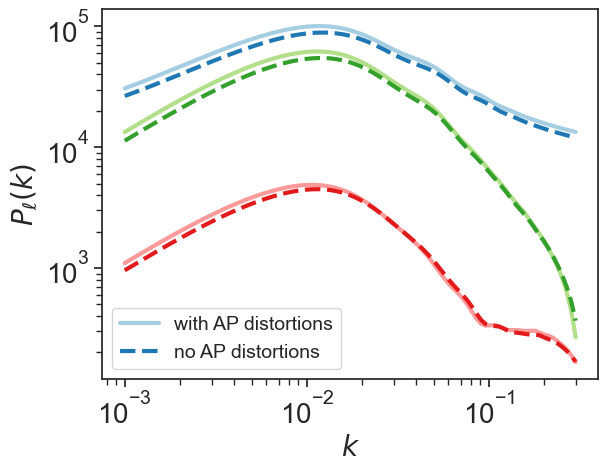

In [6]:
# Impact of AP distortions
plt.loglog(k, pell_comet['ell0'], label="with AP distortions")
plt.loglog(k, pell_comet_noAP['ell0'], ls='--', label="no AP distortions")
plt.loglog(k, pell_comet['ell2'])
plt.loglog(k, pell_comet_noAP['ell2'], ls='--')
plt.loglog(k, pell_comet['ell4'])
plt.loglog(k, pell_comet_noAP['ell4'], ls='--')
plt.xlabel(r'$k$')
plt.ylabel(r'$P_\ell(k)$')
plt.legend()

To get a prediction with different values of the nuisance parameters we only need to define new parameter dictionaries and re-create the instances of `CometEFT_SpectroPower` and `LegendreMultipoles` to get new multipoles:

In [7]:
new_RSD_parameters = {
 'b1': 2.0, 'b2': 0.695, 'bG2': -0.156, 'bGam3': 0.323,
 'c0': 30.948, 'c2': 46.233, 'c4': 10.057, 'cnlo': 0.0
}
new_noise_syst = {
 'NP0': 1.056, 'NP20': 0.0, 'NP22': 0.0,
 'fout': 0.2, 'sigmaz': 0.002
}

pkmu_comet_newrsd = CometEFT_SpectroPower(background, new_RSD_parameters, redshift=zs[0]) 

mps_comet_newrsd = LegendreMultipoles(pkmu_comet_newrsd, background_fiducial, new_noise_syst, nbar=1e-4)

pell_comet_newrsd = mps_comet_newrsd.power_multipoles(k=k, ells=[0,2,4])

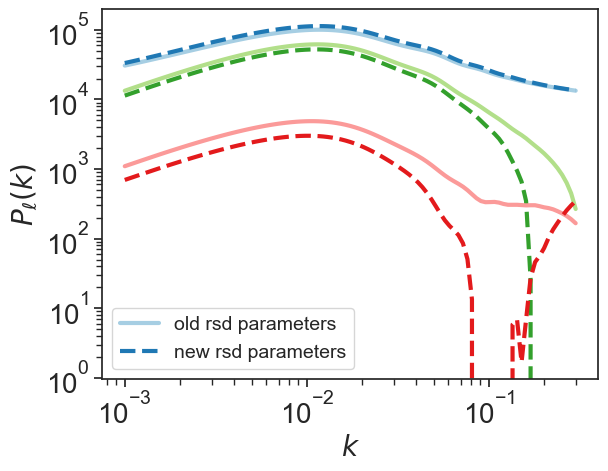

In [8]:
# Impact of RSD parameters
plt.loglog(k, pell_comet['ell0'], label="old rsd parameters")
plt.loglog(k, pell_comet_newrsd['ell0'], '--', label="new rsd parameters")
plt.loglog(k, pell_comet['ell2'])
plt.loglog(k, pell_comet_newrsd['ell2'], '--')
plt.loglog(k, pell_comet['ell4'])
plt.loglog(k, pell_comet_newrsd['ell4'], '--')
plt.xlabel(r'$k$')
plt.ylabel(r'$P_\ell(k)$')
plt.legend()

Predictions with a different cosmology can be obtained in a similar way, they only require the additional step of creating a new Background object:

In [9]:
new_background = CAMBBackground(H0=70.0, Omega_cdm0=0.25, Omega_b0=0.049, w0=-1.2, wa=0, Omega_k0 = 0.0, 
                                ns = 0.93, As = 2.1e-9, gamma_MG = 0.545, mnu=0.0, N_mnu=0)

In [10]:
pkmu_comet_newbkg = CometEFT_SpectroPower(new_background, RSD_parameters, redshift=zs[0]) 

mps_comet_newbkg = LegendreMultipoles(pkmu_comet_newbkg, background_fiducial, noise_syst_parameters, nbar=1e-4)

pell_comet_newbkg = mps_comet_newbkg.power_multipoles(k=k, ells=[0,2,4])

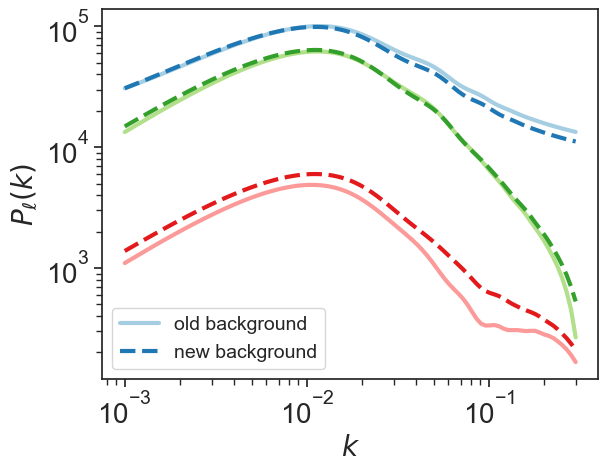

In [11]:
plt.loglog(k, pell_comet['ell0'], label='old background')
plt.loglog(k, pell_comet_newbkg['ell0'], '--', label='new background')
plt.loglog(k, pell_comet['ell2'])
plt.loglog(k, pell_comet_newbkg['ell2'], '--')
plt.loglog(k, pell_comet['ell4'])
plt.loglog(k, pell_comet_newbkg['ell4'], '--')
plt.xlabel(r'$k$')
plt.ylabel(r'$P_\ell(k)$')
plt.legend()

Finally we generate a prediction with the VDG model by adding one additional (VDG specific) parameter to the RSD parameter dictionary, and then creating a `CometVDG_SpectroPower` object, where the VDG model is imported. The steps to obtain multipoles are then the same as before:

In [12]:
RSD_parameters['avir'] = 3.0
pkmu_comet_vdg = CometVDG_SpectroPower(background, RSD_parameters, redshift=zs[0]) 

mps_comet_vdg = LegendreMultipoles(pkmu_comet_vdg, background_fiducial, noise_syst_parameters, nbar=1e-4)

pell_comet_vdg = mps_comet_vdg.power_multipoles(k=k, ells=[0,2,4])

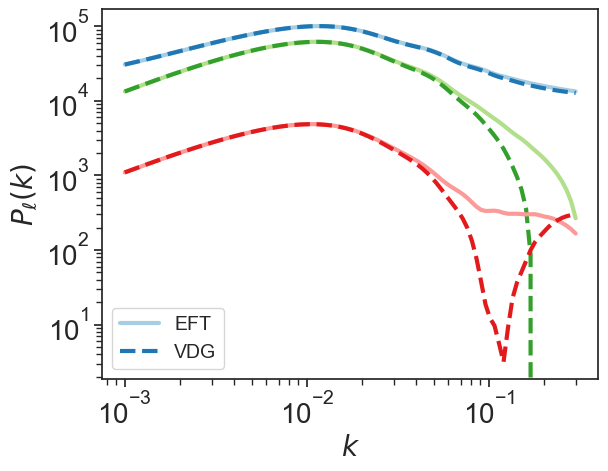

In [13]:
plt.loglog(k, pell_comet['ell0'], label="EFT")
plt.loglog(k, pell_comet_vdg['ell0'], '--', label="VDG")
plt.loglog(k, pell_comet['ell2'])
plt.loglog(k, pell_comet_vdg['ell2'], '--')
plt.loglog(k, pell_comet['ell4'])
plt.loglog(k, pell_comet_vdg['ell4'], '--')
plt.xlabel(r'$k$')
plt.ylabel(r'$P_\ell(k)$')
plt.legend()

Additionally, it is possible to obtain predictions for the individual diagrams of the one-loop models (EFT and VDG), specifying the specific terms as an extra argument in the `power_term_multipoles` method:

In [14]:
term_list = ['b1-b1', 'b1-bGam3', 'v-v']
pell_term_comet = mps_comet.power_term_multipoles(k=k, ells=[0,2,4], term_list=term_list, use_AP=True)

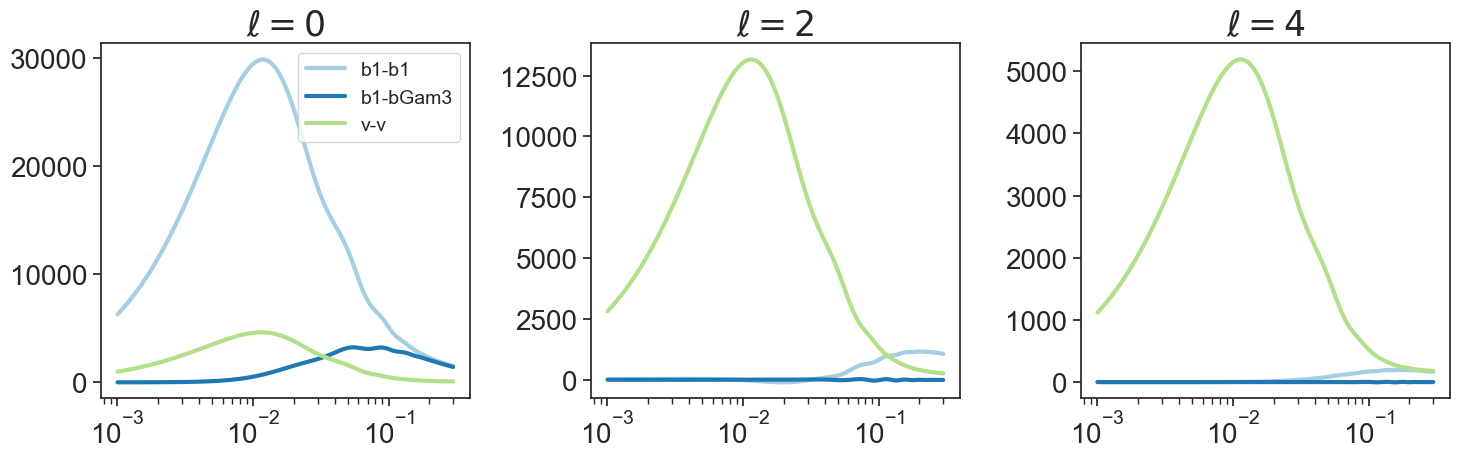

In [15]:
fig, axs = plt.subplots(1, 3, figsize=(15,5))
for j,ell in enumerate([0,2,4]):
    axs[j].set_title(rf'$\ell={ell}$')
    for i in range(pell_term_comet[f'ell{ell}'].shape[0]):
        axs[j].semilogx(k, pell_term_comet[f'ell{ell}'][i,:], label=f'{term_list[i]}')
axs[0].legend()    
plt.tight_layout()

The total list of diagrams include ('v-v' stands for the coupling of the velocity field with itself, while the cnlo terms can be selected only for the EFT model):

## Galaxy 2PCF multipoles with comet

__Warning__: The 2PCF currently only works selecting COMET as non-linear theory code. This version will be updated to have a consistent framework for different thoery codes, and more robustness of the Hankel transformation as a function of the position in cosmological and nuisance parameter space

In [16]:
s = np.linspace(30.0, 250.0, 56)

xiell_comet = mps_comet.two_point_correlation_multipoles(s=s, ells=[0,2,4])
xiell_comet_noAP = mps_comet.two_point_correlation_multipoles(s=s, ells=[0,2,4], use_AP=False)

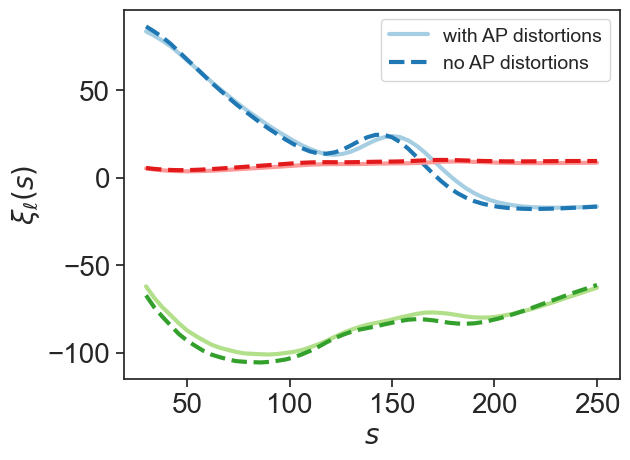

In [17]:
plt.plot(s, s**2*xiell_comet['ell0'], label="with AP distortions")
plt.plot(s, s**2*xiell_comet_noAP['ell0'], ls='--', label="no AP distortions")
plt.plot(s, s**2*xiell_comet['ell2'])
plt.plot(s, s**2*xiell_comet_noAP['ell2'], ls='--')
plt.plot(s, s**2*xiell_comet['ell4'])
plt.plot(s, s**2*xiell_comet_noAP['ell4'], ls='--')
plt.xlabel(r'$s$')
plt.ylabel(r'$\xi_\ell(s)$')
plt.legend()

## Galaxy power spectrum multipoles from PBJ
In this section we use the EFT model implemented in PBJ to create theoretical predictions, and compare to the comet predictions of the previous section.

__Warning__: this requires having PBJ installed.

In [18]:
from cloelib.observables.PBJ_spectro import PBJSpectroPower

[WARNING]: evogrowth for non LCDM growth functions not installed
[WARNING]: Bacco not installed!


We will use the same `background` and `background_fiducial` constructed at the beginning of the notebook, but for pbj we also need a `LinearPerturbations` object, because the code takes a linear power spectrum as input for the computations. We create this as an instance of `CAMBLinearPerturbations`.

In [19]:
linear_perturbations = CAMBLinearPerturbations(background, zs)

After this we are ready to compute theoretical prediction for the multipoles following the exact same steps we used above, with the only difference that we are now using an instance of the `PBJSpectroPower` object. Notice that in order to make a comparison with comet the counterterms $c_0$, $c_2$, $c_4$ must be converted, as they are parameterised differently in the two codes.

In [20]:
RSD_parameters_pbj = {
 'b1': 1.412, 'b2': 0.695, 'bG2': -0.156, 'bG3': 0.323,
 'c0': 11.602875000000001, 'c2': 35.82984756123215, 'c4': 56.439110254601786, 'ck4': 0.0
}

pkmu_pbj = PBJSpectroPower(linear_perturbations, RSD_parameters_pbj) # Notice this needs a LinearPerturbation as input
mps_pbj = LegendreMultipoles(pkmu_pbj, background_fiducial, noise_syst_parameters, nbar=1e-4)
pell_pbj = mps_pbj.power_multipoles(k=k, ells=[0,2,4])

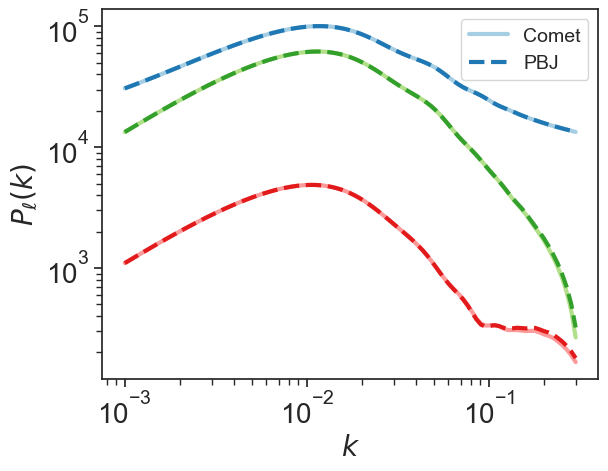

In [21]:
# Comet vs PBJ
plt.loglog(k, pell_comet['ell0'], label='Comet')
plt.loglog(k, pell_pbj['ell0'], ls='--', label='PBJ')
plt.loglog(k, pell_comet['ell2'])
plt.loglog(k, pell_pbj['ell2'], ls='--')
plt.loglog(k, pell_comet['ell4'])
plt.loglog(k, pell_pbj['ell4'], ls='--')
plt.xlabel(r'$k$')
plt.ylabel(r'$P_\ell(k)$')
plt.legend()

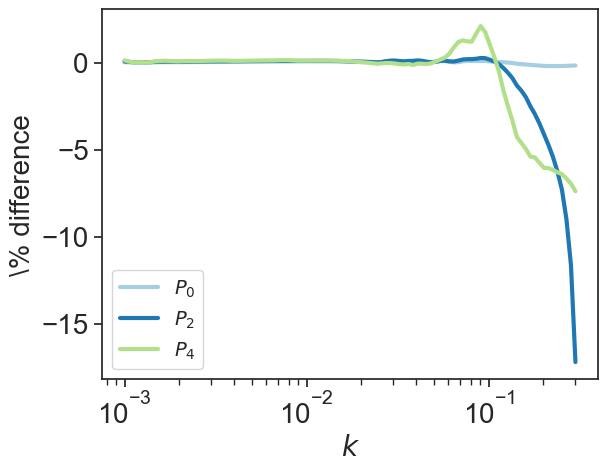

In [22]:
plt.semilogx(k, 100*(pell_comet['ell0']/pell_pbj['ell0']-1), label=r'$P_0$')
plt.semilogx(k, 100*(pell_comet['ell2']/pell_pbj['ell2']-1), label=r'$P_2$')
plt.semilogx(k, 100*(pell_comet['ell4']/pell_pbj['ell4']-1), label=r'$P_4$')
plt.ylabel(r'\% difference')
plt.xlabel(r'$k$')
plt.legend()

As before, we can change the nuisance parameters by passing a new parameter dictionary to the instance of `PBJSpectroPower`:

In [23]:
new_RSD_parameters_pbj = {
 'b1': 2.0, 'b2': 0.695, 'bG2': -0.156, 'bG3': 0.323,
 'c0': 11.602875000000001, 'c2': 35.82984756123215, 'c4': 56.439110254601786, 'ck4': 0.0
}
pkmu_pbj_newrsd = PBJSpectroPower(linear_perturbations, new_RSD_parameters_pbj) 
mps_pbj_newrsd = LegendreMultipoles(pkmu_pbj_newrsd, background_fiducial, new_noise_syst, nbar=1e-4)
pell_pbj_newrsd = mps_pbj_newrsd.power_multipoles(k=k, ells=[0,2,4])

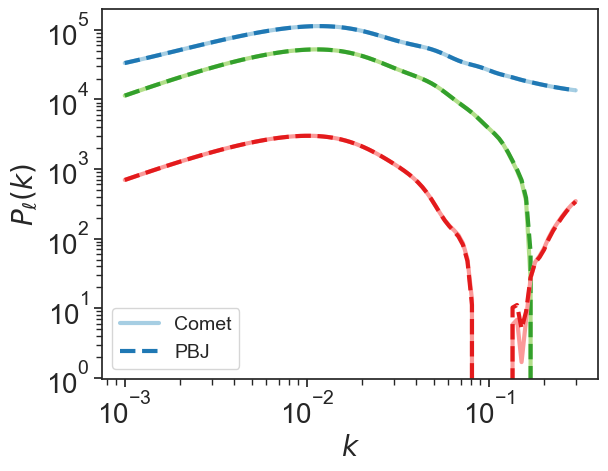

In [24]:
plt.loglog(k, pell_comet_newrsd['ell0'], label='Comet')
plt.loglog(k, pell_pbj_newrsd['ell0'], ls='--', label='PBJ')
plt.loglog(k, pell_comet_newrsd['ell2'])
plt.loglog(k, pell_pbj_newrsd['ell2'], ls='--')
plt.loglog(k, pell_comet_newrsd['ell4'])
plt.loglog(k, pell_pbj_newrsd['ell4'], ls='--')
plt.xlabel(r'$k$')
plt.ylabel(r'$P_\ell(k)$')
plt.legend()

Changing the background cosmology requires the additional step of creating a new `LinearPerturbations` object. Additionally, to match the comet prediction we need to rescale the values of the counterterms by a factor $(h_{\rm old}/h_{\rm new})^2$, as the change of basis from one parameterisation to the other is cosmology dependent:

In [25]:
new_linear_perturbations = CAMBLinearPerturbations(new_background, zs)

RSD_parameters_pbj['c0'] *= background.h**2/new_background.h**2
RSD_parameters_pbj['c2'] *= background.h**2/new_background.h**2
RSD_parameters_pbj['c4'] *= background.h**2/new_background.h**2

pkmu_pbj_newbkg = PBJSpectroPower(new_linear_perturbations, RSD_parameters_pbj) 
mps_pbj_newbkg = LegendreMultipoles(pkmu_pbj_newbkg, background_fiducial, noise_syst_parameters, nbar=1e-4)
pell_pbj_newbkg = mps_pbj_newbkg.power_multipoles(k=k, ells=[0,2,4])

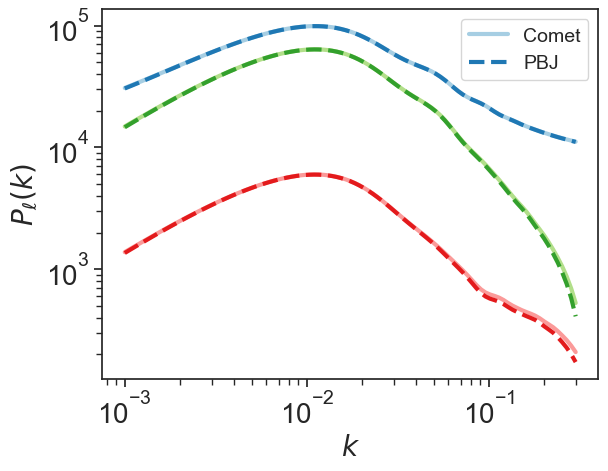

In [26]:
plt.loglog(k, pell_comet_newbkg['ell0'], label='Comet')
plt.loglog(k, pell_pbj_newbkg['ell0'], ls='--', label='PBJ')
plt.loglog(k, pell_comet_newbkg['ell2'])
plt.loglog(k, pell_pbj_newbkg['ell2'], ls='--')
plt.loglog(k, pell_comet_newbkg['ell4'])
plt.loglog(k, pell_pbj_newbkg['ell4'], ls='--')
plt.xlabel(r'$k$')
plt.ylabel(r'$P_\ell(k)$')
plt.legend()

As for `comet`, it is possible to obtain predictions for the individual diagrams of the one-loop EFT model, selecting the specific terms as an extra argument in the `power_term_multipoles` method. There are however some differences, as for `pbj` the only possible outputs are the analytically marginalisable terms, shot noise excluded (`'bG3'`,`'c0'`, `'c2'`, `'c4'`, `'ck4'`).

Note also that the individual terms returned by the two codes (`comet` and `pbj`) are not the same because in comet the terms are not resummed while in PBJ they are. For example, the `cnlo` (or `ck4`) term can be written as: 
$$c_{\rm nlo}~f^4~\mu^4~k^4(b_1 + f~\mu^2)^2~P_L(k)$$

`comet` returns three terms, `b1-b1-cnlo`:$\mu^4~k^4~P_L(k)$, `b1-cnlo`: $\mu^6~k^4~P_L(k)$, `cnlo`: $\mu^8~k^4~P_L(k)$, while `pbj` returns a single term `ck4`, already resummed. This difference does not impact the ability to run a likelihood with analytic marginalisation with either code, provided the likelihood resums (or not) the relevant terms. The behaviour will be standardized in a future PR.

In [27]:
term_list = ['c0', 'c2', 'c4']
pell_term_pbj = mps_pbj.power_term_multipoles(k=k, ells=[0,2,4], term_list=term_list, use_AP=True)

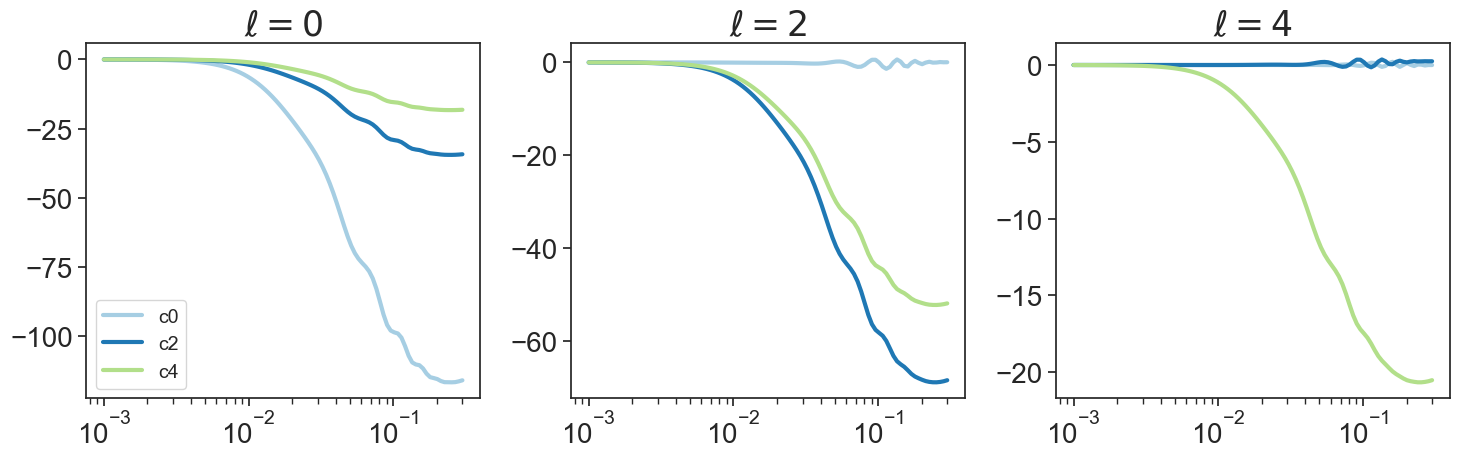

In [28]:
fig, axs = plt.subplots(1, 3, figsize=(15,5))
for j,ell in enumerate([0,2,4]):
    axs[j].set_title(rf'$\ell={ell}$')
    for i in range(pell_term_pbj[f'ell{ell}'].shape[0]):
        axs[j].semilogx(k, pell_term_pbj[f'ell{ell}'][i,:], label=f'{term_list[i]}')
axs[0].legend()    
plt.tight_layout()

## Convolution with mixing matrix
In this section, we show how to obtain predictions for the galaxy power spectrum multipoles convolved with a specific survey mixing matrix.

At the moment there are ongoing developments for reading GCspectro data (including the mixing matrix) within Euclidlib. As soon as this is finalised, the reading of the different quantities will be realised within that package. For the time being, we do it here to demonstrate how the convolution works. The mixing matrix we use in this case is just an identity matrix, so we don't have any change between the two cases.

In [29]:
# Execute this cell to download the test mixing matrices (only identity)
data_downloaded = False

if data_downloaded == False:
    
    import requests
    
    # URLs of the files to be downloaded
    urls = {
        'mixmat_identity_z1..fits': 'https://zenodo.org/records/15543831/files/mixmat_identity_z1..fits',
    }
    
    # Function to download a file
    def download_file(url, filename):
        response = requests.get(url)
        if response.status_code == 200:
            with open(filename, 'wb') as f:
                f.write(response.content)
            print(f'{filename} downloaded successfully')
        else:
            print(f'Failed to download {filename}. Status code: {response.status_code}')
    
    # Download all files
    for filename, url in urls.items():
        download_file(url, filename)

mixmat_identity_z1..fits downloaded successfully


In [30]:
# Here we load a mixing matrix and store it into a dictionary
fits_file = fits.open('mixmat_identity_z1..fits')

k_fac = background.h
kin0 = fits_file['BINS_INPUT'].data['kp0'] * k_fac
kin2 = fits_file['BINS_INPUT'].data['kp2'] * k_fac
kin4 = fits_file['BINS_INPUT'].data['kp4'] * k_fac
kout = fits_file['BINS_OUTPUT'].data['k'] * k_fac
mixing_matrix = fits_file['MIXING_MATRIX'].data

mixing_matrix_dict = {}

mixing_matrix_dict['kout'] = kout
mixing_matrix_dict['kin0'] = kin0
mixing_matrix_dict['kin2'] = kin2
mixing_matrix_dict['kin4'] = kin4
for i in [0, 2, 4]:
    for j in [0, 2, 4]:
        mm = f'W{i}{j}'
        mixing_matrix_dict[mm] = mixing_matrix[mm]

# Now we call a specific function of the LegendreMultipoles class that accepts the mixing matrix as input.
# The value of k at which the multipoles are computed match the BINS_OUTPUT table
pell_comet_conv = mps_comet.convolved_power_multipoles(mixing_matrix_dict, ells=[0, 2, 4])

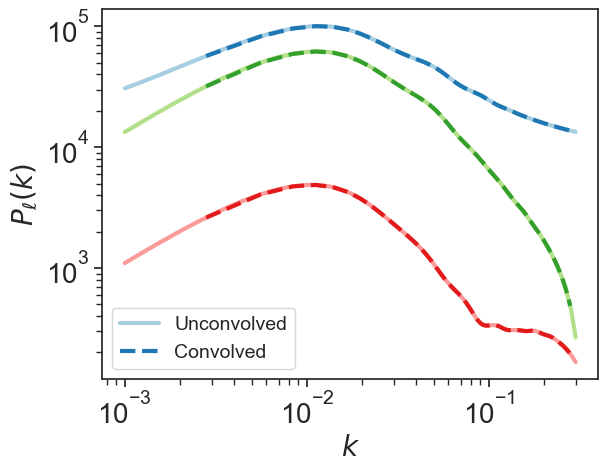

In [31]:
plt.loglog(k, pell_comet['ell0'], label='Unconvolved')
plt.loglog(kout, pell_comet_conv['ell0'], label='Convolved', ls='--')
plt.loglog(k, pell_comet['ell2'])
plt.loglog(kout, pell_comet_conv['ell2'], ls='--')
plt.loglog(k, pell_comet['ell4'])
plt.loglog(kout, pell_comet_conv['ell4'], ls='--')
plt.xlabel(r'$k$')
plt.ylabel(r'$P_\ell(k)$')
plt.legend()

In [32]:
term_list = ['b1-b1', 'b1-bGam3', 'v-v']
pell_term_comet_conv = mps_comet.convolved_power_term_multipoles(mixing_matrix_dict, term_list=term_list, ells=[0,2,4], use_AP=True)

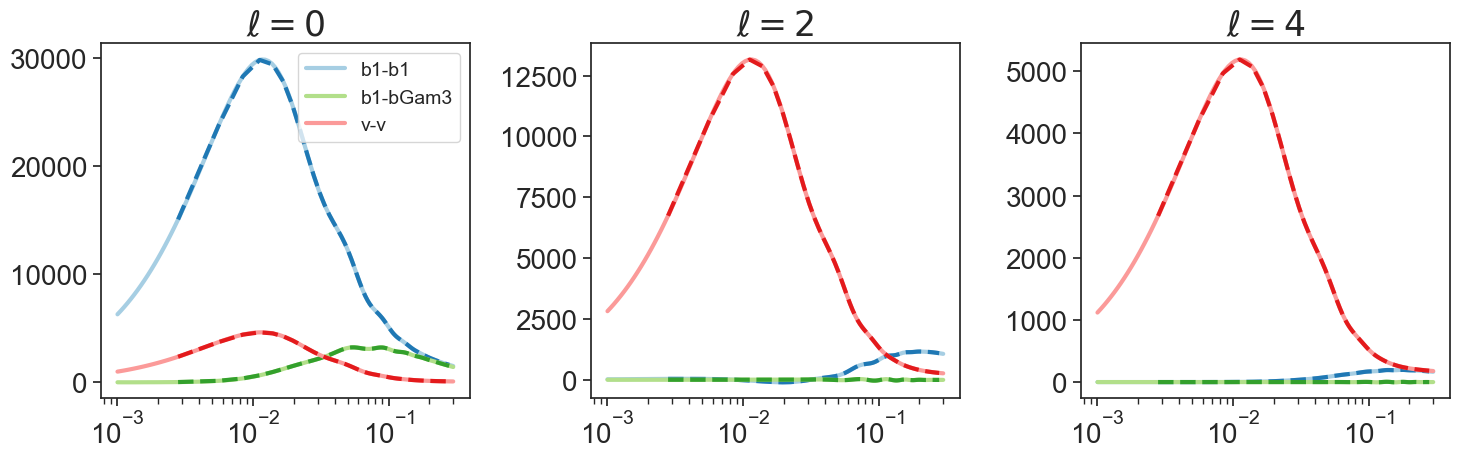

In [33]:
fig, axs = plt.subplots(1, 3, figsize=(15,5))
for j,ell in enumerate([0,2,4]):
    axs[j].set_title(rf'$\ell={ell}$')
    for i in range(pell_term_comet[f'ell{ell}'].shape[0]):
        axs[j].semilogx(k, pell_term_comet[f'ell{ell}'][i,:], label=f'{term_list[i]}')
        axs[j].semilogx(kout, pell_term_comet_conv[f'ell{ell}'][i,:], ls='--')
axs[0].legend()    
plt.tight_layout()